In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("LabDelSole.pickle")
df_mercatini = pd.read_pickle("mercatini.pickle")

colori = sns.color_palette("pastel")

In [10]:
#IMPORTANTE, QUI CREIAMO UN DF PER LA VISIONE TEMPORALE

ordine_stagioni = [
    "aut 23", "inv 23", 
    "prim 24", "est 24", "aut 24", "inv 24", 
    "prim 25", "est 25", "aut 25", "inv 25", 
    "prim 26", "est 26"
]

df_stagionale = pd.DataFrame({
    "guadagno totale": df["venduti"].T.dot(df[("info", "prezzo")]),
    "mercatini": df["mercatino"].T.dot(df[("info", "prezzo")]),
    "commissioni": df["passaparola"].T.dot(df[("info", "prezzo")]),
    "ore": df["venduti"].T.dot(df[("info", "ore impiegate")])
})

df_stagionale = df_stagionale.reindex(ordine_stagioni)
df_stagionale = df_stagionale.reset_index().rename(columns={"index": "stagione"})
df_stagionale["prezzo_ora"] = df_stagionale["guadagno totale"] / df_stagionale["ore"]

df_stagionale

,stagione,guadagno totale,mercatini,commissioni,ore,prezzo_ora
0,aut 23,145.0,NaN,145.0,19.5,7.435897
1,inv 23,195.0,NaN,195.0,27.0,7.222222
2,prim 24,140.0,NaN,140.0,15.5,9.032258
3,est 24,475.0,250.0,225.0,50.5,9.405941
4,aut 24,225.0,NaN,225.0,26.0,8.653846
5,inv 24,360.0,115.0,245.0,34.5,10.434783
6,prim 25,125.0,NaN,125.0,11.0,11.363636
7,est 25,150.0,NaN,150.0,16.0,9.375000
8,aut 25,230.0,100.0,130.0,24.0,9.583333
9,inv 25,185.0,NaN,185.0,19.5,9.487179


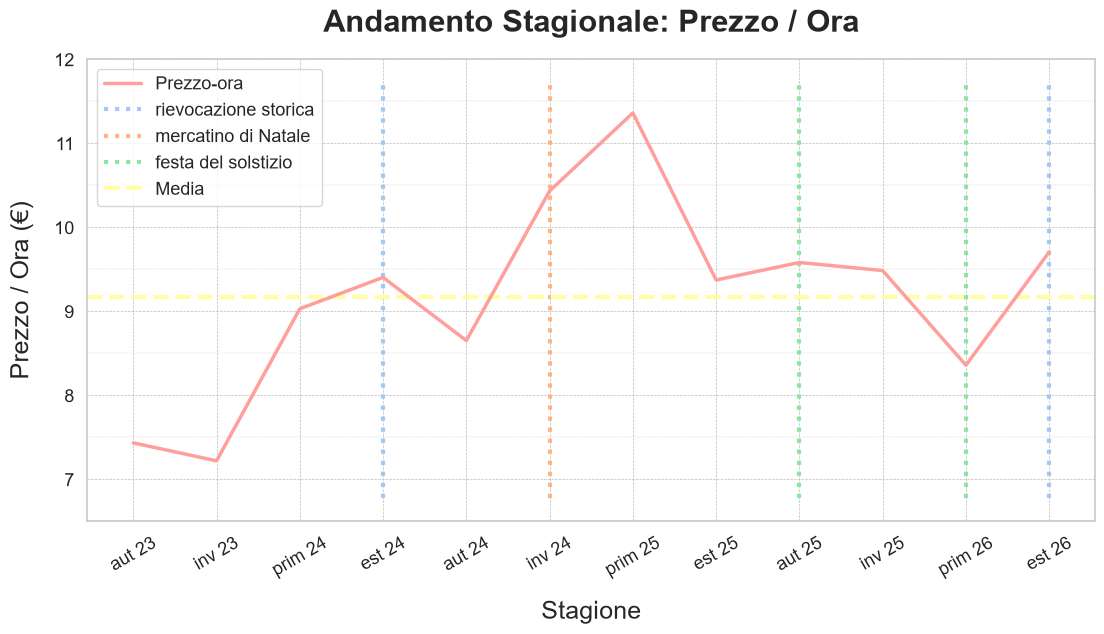

In [11]:
sns.set_theme(style="whitegrid", font_scale = 1.2)

fig, ax = plt.subplots(figsize = (13, 6))

sns.lineplot(
    data=df_stagionale, 
    x="stagione", 
    y="prezzo_ora", 
    linewidth=2.5, 
    color=colori[3],
    label="Prezzo-ora",
    zorder=3
)

ax.set_facecolor("#FFFFFF")

ax.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax.grid(True, axis = 'y', which = 'minor',linewidth = 0.3, linestyle="--")

posizioni = {stagione: i for i, stagione in enumerate(ordine_stagioni)}
nomi_eventi = df_mercatini["evento"].unique() #no doppioni
colore_eventi = {} #dizionario nome-colore
for i, nome in enumerate(nomi_eventi):
    colore_eventi[nome] = colori[i]
gia_in_legenda = [] #non li vogliamo ripeter

for _, riga in df_mercatini.iterrows():
    x = posizioni.get(riga["stagione"])
    if x is None: #non dovrebbe mai entrare ma non si sa mai errori di battitura nel csv
        continue    
    nome = riga["evento"]
    colore = colore_eventi[nome]
    if nome in gia_in_legenda: #sempre perche non vogliamo la stessa etichetta piu volte
        etichetta = None
    else:
        etichetta = nome
        gia_in_legenda.append(nome)
    
    ax.axvline(
        x,
        color=colore,
        linewidth=3,
        linestyle=":",
        ymin=0.05,
        ymax=0.95,
        label=etichetta #puo essere quindi None o nome
    )

ax.axhline(
        df_stagionale["prezzo_ora"].mean(),
        color=colori[8],
        linewidth=3,
        linestyle="--",
        label="Media" #puo essere quindi None o nome
    )

ax.set_title("Andamento Stagionale: Prezzo / Ora", pad = 20, fontsize = 22, fontweight = "bold")
ax.set_xlabel("Stagione", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_ylabel("Prezzo / Ora (€)", fontsize = 18, fontweight = "normal", labelpad = 15)

ax.yaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.set_ylim(6.5, 12)
ax.legend(loc="upper left")
plt.xticks(rotation=30)

plt.savefig("Immagini/Prezzo-Ora.svg", bbox_inches = "tight", pad_inches = 0.1, transparent = False)
plt.savefig("Immagini/Prezzo-Ora.png", bbox_inches = "tight", pad_inches = 0.1, transparent = False)

In [12]:
df_stagionale = df_stagionale.drop(columns=["guadagno totale", "ore", "prezzo_ora"])
df_stagionale = df_stagionale.set_index("stagione")
df_stagionale

,mercatini,commissioni
stagione,,
aut 23,NaN,145.0
inv 23,NaN,195.0
prim 24,NaN,140.0
est 24,250.0,225.0
aut 24,NaN,225.0
inv 24,115.0,245.0
prim 25,NaN,125.0
est 25,NaN,150.0
aut 25,100.0,130.0


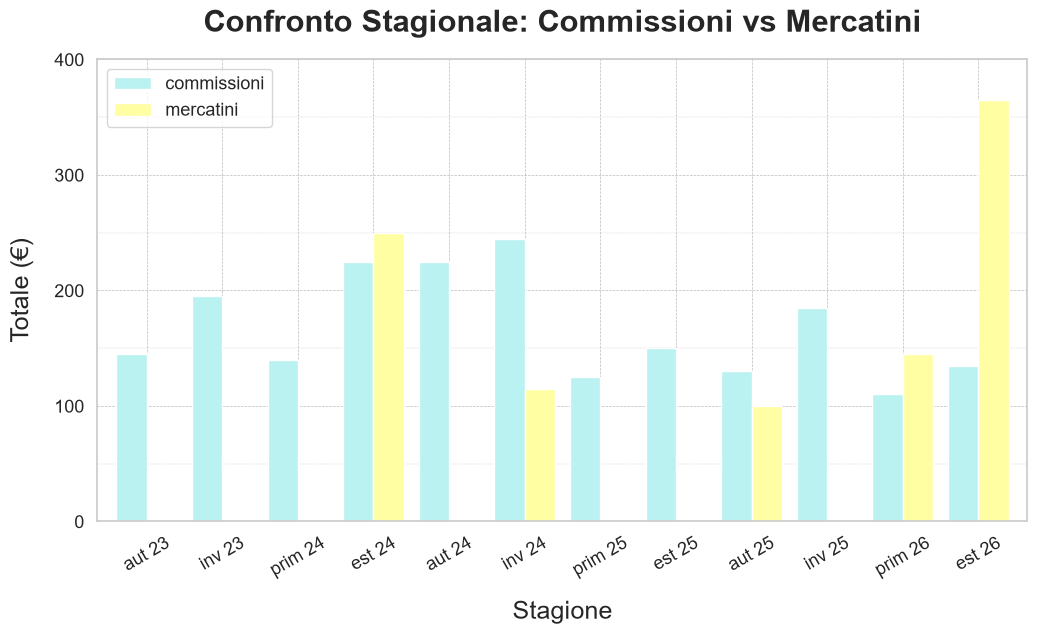

In [13]:
ordine=["commissioni", "mercatini"]

ax = df_stagionale[ordine].plot(kind="bar", figsize=(12, 6), width=0.8, color=[colori[9], colori[8]])

ax.grid(True, color = "#BBBBBB", linewidth = 0.5, linestyle="--")
ax.grid(True, axis = 'y', which = 'minor', linewidth = 0.3, linestyle="--")

ax.set_xlabel("Stagione", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_ylabel("Totale (€)", fontsize = 18, fontweight = "normal", labelpad = 15)
ax.set_title("Confronto Stagionale: Commissioni vs Mercatini", pad = 20, fontsize = 22, fontweight = "bold")

ax.yaxis.set_major_locator(plt.MultipleLocator(100))
ax.yaxis.set_minor_locator(plt.MultipleLocator(50))
ax.set_ylim(0, 400)

plt.xticks(rotation=30)
plt.legend(loc="upper left")

plt.savefig("Immagini/Passaparola-Mercatini.svg", bbox_inches = "tight", pad_inches = 0.1, transparent = False)
plt.savefig("Immagini/Passaparola-Mercatini.png", bbox_inches = "tight", pad_inches = 0.1, transparent = False)